## Table of Contents

- [Setup and Imports](#setup-imports)
- [Task 1: Exploratory Data Analysis](#task-1)
- [Task 2(a): Naive Bayes](#task-2a)
- [Task 2(b): k-Nearest Neighbours](#task-2b)
- [Task 2(c): Support Vector Machines](#task-2c)
- [Task 2(d): Artificial Neural Network](#task-2d)
- [Task 3(a): Hyperparameter Investigation For Each Classifier](#task-3a)
- [Task 3(b): Best Model Comparison on Test Set](#task-3b)
- [Task 3(c): Effect of Training Set Size](#task-3c)
- [Final Summary](#final-summary)

<a id="setup-imports"></a>
## Setup

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Imports for artificial neural network
from sklearn.neural_network import MLPClassifier
from sklearn.feature_extraction.text import TfidfVectorizer

# Imports for classifier evaluation
from sklearn.model_selection import cross_val_score

## 1. Task 1: Exploratory Data Analysis

(a) Load the datasets and construct a feature vector for each article. You need to report the number of
articles, and the number of extracted features per dataset (train and test). Show 5 example articles with
their extracted features using a dataframe.

(b) Conduct term frequency analysis on the train dataset and report three plots: (i) top-50 term
frequency distribution (ii) term frequency distribution per class and (iii) class distribution for the train and
test dataset.
You can use the same vectorization approaches you have explored in Assignment 2 to extract features from
text data (e.g. CountVectorizer() and TfidfVectorizer() in sklearn). If you use other approaches, explain them
briefly.

In [4]:
# Load the data
train_df = pd.read_csv('data/train.csv')

# Vectorize the text
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train_df['Article'])
y_train = train_df['Category']

<a id="task-2d"></a>
## Task 2(d): Artificial Neural Network

For this task, we train a single-hidden-layer neural network on the training dataset.

The network uses the following required hyperparameters:

- Initial weights uniformly drawn from the range $[0, 0.1]$
- Learning rate: $0.01$
- Number of training epochs: $100$
- Hidden units: $h \in \{2, 5, 20, 40\}$

The input layer consists of the extracted text feature vector for each article:

$$
x = [x_1, x_2, \ldots, x_n]^T
$$

The hidden layer contains $h$ hidden units:

$$
z = [z_1, z_2, \ldots, z_h]^T
$$

The output layer gives a probability distribution over the two classes:

$$
y = [y_1, y_2]^T
$$

We train the model separately for each value of $h$, then plot the final binary cross-entropy loss on the training data against the number of hidden units. Finally, we briefly discuss how changing the number of hidden units affects the model.

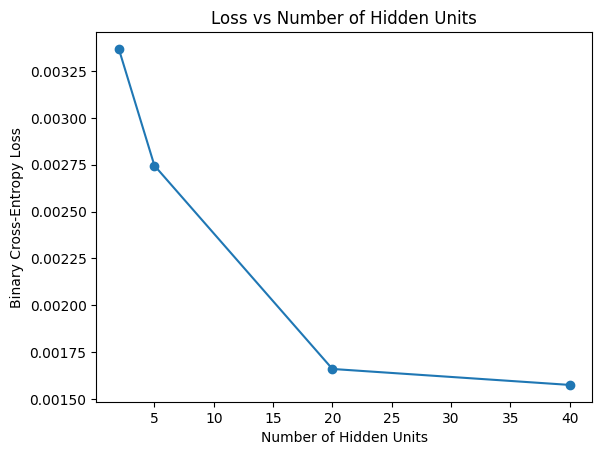

In [5]:
hidden_units = [2, 5, 20, 40]
losses = []

# Train the model with different numbers of hidden units and record the loss
for h in hidden_units:
    model = MLPClassifier(
        hidden_layer_sizes=(h,),
        learning_rate_init=0.01,
        max_iter=100,
        random_state=42
    )
    model.fit(X_train, y_train)
    losses.append(model.loss_)  # final training loss

# Plot the results
plt.plot(hidden_units, losses, marker='o')
plt.xlabel('Number of Hidden Units')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Loss vs Number of Hidden Units')
plt.show()

### Report / Reasoning

As the number of hidden units increases, the training loss tends to decrease. This is because more hidden units give the model greater capacity to learn complex patterns in the data. However, beyond a certain point, the improvements become smaller, adding more units yields diminishing returns. Additionally, too many hidden units risks overfitting the model to the training data, which would hurt performance on unseen data.

## Task 3(a): Hyperparameter Investigation For Each Classifier

(a) Investigate the impact of key hyperparameters of your choice for each classifier using 5-fold crossvalidation. 

E.g., for SVM, the classification accuracy may be significantly affected by the kernels and associated hyperparameters. List hyperparameters for each classifier and demonstrate how these hyperparameters impact the model performance (cross-validation performance). [1 pt] 